In [1]:
from vizdoom import *
import cv2
import numpy as np
import time
import os
from tqdm import tqdm
from collections import deque

import gymnasium as gym
from gymnasium import Env
from gymnasium.spaces import Discrete, Box

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

In [2]:
# Instantiate TakeCover environment
CONFIG_PATH = './github/ViZDoom/scenarios/take_cover.cfg'
CACHE_PATH = './logs/policy_cache.json'
N_STACK = 4         
N_EPISODES = 1000       
BOOTSTRAP_REPS = 2000

COLORS = {
    "Baseline":              "#006AFF",
    "Llama Reward Agent":    "#00FFAA",
    "Qwen Reward Agent":     "#F2FF00",
    "Llama Policy Agent":    "#9000FF",
    "Qwen Policy Agent":     "#FF0080",
}

In [3]:
# Create Vizdoom OpenAI Gym Environment
class VizDoomGym(Env): 
    def __init__(self, render=False): 
        # Setup the game 
        super().__init__()
        self.frame_skip = 4
        self.game = DoomGame()
        self.game.load_config(CONFIG_PATH)
        
        # Render frame logic
        self.game.set_window_visible(render)

        # Start the game 
        self.game.init()
        
        # Create the action space and observation space
        self.observation_space = Box(low=0, high=255, shape=(100,160,1), dtype=np.uint8) 
        self.action_space = Discrete(2) # Move left, move right
        self._actions = np.eye(2, dtype=np.uint8)

        self._episode_start_tic: int = 0
        
    # This is how we take a step in the environment
    def step(self, action):
        # Specify action and take step 
        reward = self.game.make_action(self._actions[action].tolist(), self.frame_skip) 

        # Get the new state of the game and check if it's done
        if self.game.get_state(): 
            obs = self._process_frame(self.game.get_state().screen_buffer)
        else: 
            obs = np.zeros(self.observation_space.shape, dtype=np.uint8)
        
        terminated = self.game.is_episode_finished()

        return obs, reward, terminated, False, {}
    
    # Define how to render the game or environment 
    def render(self): 
        pass
    
    # Starting a new game 
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.game.new_episode()
        self._episode_start_tic = self.game.get_episode_start_time()
        state = self.game.get_state()
        obs   = self._process_frame(state.screen_buffer) if state else np.zeros(self.observation_space.shape, dtype=np.uint8)
        return obs, {}
    
    def get_survival_tics(self):
        #Returns the number of tics survived in the last completed episode
        return self.game.get_episode_time() - self._episode_start_tic
    
    # Call to close down the game
    def close(self): 
        self.game.close()

    def _process_frame(self, buffer: np.ndarray):
        hwc  = np.moveaxis(buffer, 0, -1)                           
        gray = cv2.cvtColor(hwc, cv2.COLOR_RGB2GRAY)               
        resized = cv2.resize(gray, (160, 100), interpolation=cv2.INTER_CUBIC)
        clipped = np.clip(resized, 0, 255).astype(np.uint8)         
        return clipped.reshape(100, 160, 1)

In [4]:
class FrameStackWrapper:
    def __init__(self, env: VizDoomGym, n_stack: int = 4):
        self.env     = env
        self.n_stack = n_stack
        self._frames = deque(maxlen=n_stack)

    def reset(self):
        obs, info = self.env.reset()
        for _ in range(self.n_stack):
            self._frames.append(obs)
        return self._stack(), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._frames.append(obs)
        return self._stack(), reward, terminated, truncated, info

    def get_survival_tics(self):
        return self.env.get_survival_tics()

    def close(self):
        self.env.close()

    def _stack(self):
        # shape: (H, W, C*n_stack)  –  same layout as VecFrameStack 'last'
        return np.concatenate(list(self._frames), axis=-1)

In [5]:
def _bootstrap_median_ci(data, reps=BOOTSTRAP_REPS, ci=0.95):
    medians = [np.median(np.random.choice(data, size=len(data), replace=True)) for _ in range(reps)]
    alpha = (1 - ci) / 2
    return np.quantile(medians, alpha), np.quantile(medians, 1 - alpha)

# STATS TABLE
def compute_stats(name, times, threshold):
    ci_lo, ci_hi = _bootstrap_median_ci(times)
    return {
        "Agent":      name,
        "Mean":       np.mean(times),
        "Std":        np.std(times),
        "Median":     np.median(times),
        "CI_lo":      ci_lo,
        "CI_hi":      ci_hi,
        "P25":        np.percentile(times, 25),
        "P75":        np.percentile(times, 75),
        "P95":        np.percentile(times, 95),
        f"% > {threshold}": 100 * np.mean(times > threshold),
    }


def print_stats_table(stats_list):
    header = f"{'Agent':<26} {'Mean':>7} {'Std':>7} {'Median':>8} " \
             f"{'95% CI':>16} {'IQR':>9} {'P95':>7} {'%>thr':>7}"
    print("\n" + "─" * len(header))
    print(header)
    print("─" * len(header))
    for s in stats_list:
        iqr = s["P75"] - s["P25"]
        ci  = f"[{s['CI_lo']:.0f}, {s['CI_hi']:.0f}]"
        pct = list(s.values())[-1]        # last key is "% > threshold"
        print(f"{s['Agent']:<26} {s['Mean']:>7.1f} {s['Std']:>7.1f} "
              f"{s['Median']:>8.1f} {ci:>16} {iqr:>9.1f} {s['P95']:>7.1f} {pct:>6.1f}%")
    print("─" * len(header))

In [6]:
def evaluate_agent(agent_fn, n_episodes = N_EPISODES,use_framestack = False):
    raw_env = VizDoomGym()
    env     = FrameStackWrapper(raw_env, N_STACK) if use_framestack else raw_env

    survival_times:  list[int]   = []
    episode_rewards: list[float] = []

    for _ in tqdm(range(n_episodes), leave=False):
        obs, _         = env.reset()
        done           = False
        episode_reward = 0.0

        while not done:
            action = agent_fn(obs)          
            obs, reward, done, _, _ = env.step(action)
            episode_reward += reward

        survival_times.append(env.get_survival_tics())
        episode_rewards.append(episode_reward)

    env.close()
    return np.array(survival_times), np.array(episode_rewards)

In [7]:
def make_ppo_fn(model):
    def fn(obs):
        action, _ = model.predict(obs[np.newaxis], deterministic=True)
        return int(action[0])
    return fn

In [8]:
# PLOT  (KDE ridge + box + stat annotation)
def plot_results(results: dict[str, np.ndarray], save_path: str = "./logs/survival_analysis.png"):
    names  = list(results.keys())
    n = len(names)
    colors = [COLORS.get(k, "#888780") for k in names]

    fig, axes = plt.subplots(1, 2, figsize=(17, 5))
    fig.patch.set_facecolor("#FAFAF8")

    def _style(ax):
        ax.set_facecolor("#FAFAF8")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#D3D1C7")
        ax.tick_params(colors="#5F5E5A", labelsize=9)

    all_times = np.concatenate(list(results.values()))
    t_max     = int(np.max(all_times))
    t_disc    = np.arange(0, t_max + 1)

    # Survival curve P(T ≥ t)
    ax = axes[0]
    _style(ax)
    for name, color in zip(names, colors):
        arr  = results[name]
        surv = np.array([np.mean(arr >= t) for t in t_disc])
        ax.plot(t_disc, surv * 100, color=color, linewidth=2, label=name)

    # Dynamic threshold drawn from the final computed value
    ax.axvline(
        SURVIVAL_THRESHOLD, color="#888780", linewidth=1, linestyle=":",
        label=f"threshold = {SURVIVAL_THRESHOLD}"
    )
    ax.set_xlabel("Survival Time (tics)", fontsize=10, color="#444441")
    ax.set_ylabel("Survived Episodes (%)", fontsize=10, color="#444441")
    ax.set_title("Survival Curve [P(T ≥ t)]", fontsize=11, color="#2C2C2A", fontweight="500", pad=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis="y", color="#E0DED8", linewidth=0.5, linestyle="--")

    # Box-plot (time in seconds)
    ax = axes[1]
    _style(ax)
    t_max_sec = t_max / 35
    data      = [results[name] / 35 for name in names]
    bp = ax.boxplot(
        data, patch_artist=True, widths=0.45,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color="#B4B2A9", linewidth=1),
        capprops=dict(color="#B4B2A9", linewidth=1),
        flierprops=dict(marker=".", markersize=2, alpha=0),
    )
    for i, (d, color) in enumerate(zip(data, colors), 1):
        bp["boxes"][i - 1].set_facecolor(color)
        bp["boxes"][i - 1].set_alpha(0.80)
        med = np.median(d)
        ax.text(i, med + t_max_sec * 0.01, f"{med:.1f}s",
                ha="center", va="bottom", fontsize=8, color="black", fontweight="600")

    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels([name.replace(" ", "\n") for name in names], fontsize=8, color="#444441")
    ax.set_ylabel("Survival Time (seconds)", fontsize=10, color="#444441")
    ax.set_title("Survival Time Distribution", fontsize=11, color="#2C2C2A", fontweight="500", pad=10)
    ax.grid(axis="y", color="#E0DED8", linewidth=0.5, linestyle="--")

    plt.tight_layout(pad=2.5)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nPlot saved to: {save_path}")

### Agents Comparison Stats

In [9]:
baseline_agent     = PPO.load("models/baseline/best_model.zip")
llama_reward_agent = PPO.load("models/llm_reward/LLAMA/best_model.zip")
qwen_reward_agent  = PPO.load("models/llm_reward/QWEN/best_model.zip")
llama_policy_agent = PPO.load("models/llm_policy/LLAMA/best_model.zip")
qwen_policy_agent  = PPO.load("models/llm_policy/QWEN/best_model.zip")

In [10]:
print("Computing survival threshold from baseline (100 episodes)…")
baseline_times_calib, _ = evaluate_agent(
    make_ppo_fn(baseline_agent), n_episodes=100, use_framestack=True
)
SURVIVAL_THRESHOLD = int(np.percentile(baseline_times_calib, 25))
print(f"Survival threshold (P25 Baseline): {SURVIVAL_THRESHOLD} tics\n")

Computing survival threshold from baseline (100 episodes)…


Survival threshold (P25 Baseline): 457 tics



In [11]:
agents = [
    ("Baseline",           baseline_agent,     True),
    ("Llama Reward Agent", llama_reward_agent, True),
    ("Qwen Reward Agent",  qwen_reward_agent,  True),
    ("Llama Policy Agent", llama_policy_agent, True),
    ("Qwen Policy Agent",  qwen_policy_agent,  True),
]

all_survival_data: dict[str, np.ndarray] = {}
all_stats:         list[dict]            = []

for name, model, use_fs in agents:
    print(f"\nEvaluating: {name}")
    t0 = time.time()
    times, _ = evaluate_agent(make_ppo_fn(model), n_episodes=N_EPISODES, use_framestack=use_fs)
    print(f"  → done in {time.time() - t0:.1f}s")
    all_survival_data[name] = times
    all_stats.append(compute_stats(name, times, SURVIVAL_THRESHOLD))


Evaluating: Baseline


  → done in 1225.1s

Evaluating: Llama Reward Agent


  → done in 981.7s

Evaluating: Qwen Reward Agent


  → done in 1199.2s

Evaluating: Llama Policy Agent


  → done in 345.1s

Evaluating: Qwen Policy Agent


  → done in 229.3s



Full comparison

──────────────────────────────────────────────────────────────────────────────────────────────
Agent                         Mean     Std   Median           95% CI       IQR     P95   %>thr
──────────────────────────────────────────────────────────────────────────────────────────────
Baseline                     933.9   626.5    792.5       [751, 850]     770.2  2166.1   75.9%
Llama Reward Agent           766.8   485.5    670.5       [634, 695]     595.0  1661.2   71.6%
Qwen Reward Agent            943.6   581.4    841.0       [790, 886]     776.5  2013.8   78.4%
Llama Policy Agent           270.8   106.8    253.0       [244, 261]     143.2   470.1    6.2%
Qwen Policy Agent            177.9    52.6    169.0       [165, 173]      69.0   282.1    0.0%
──────────────────────────────────────────────────────────────────────────────────────────────


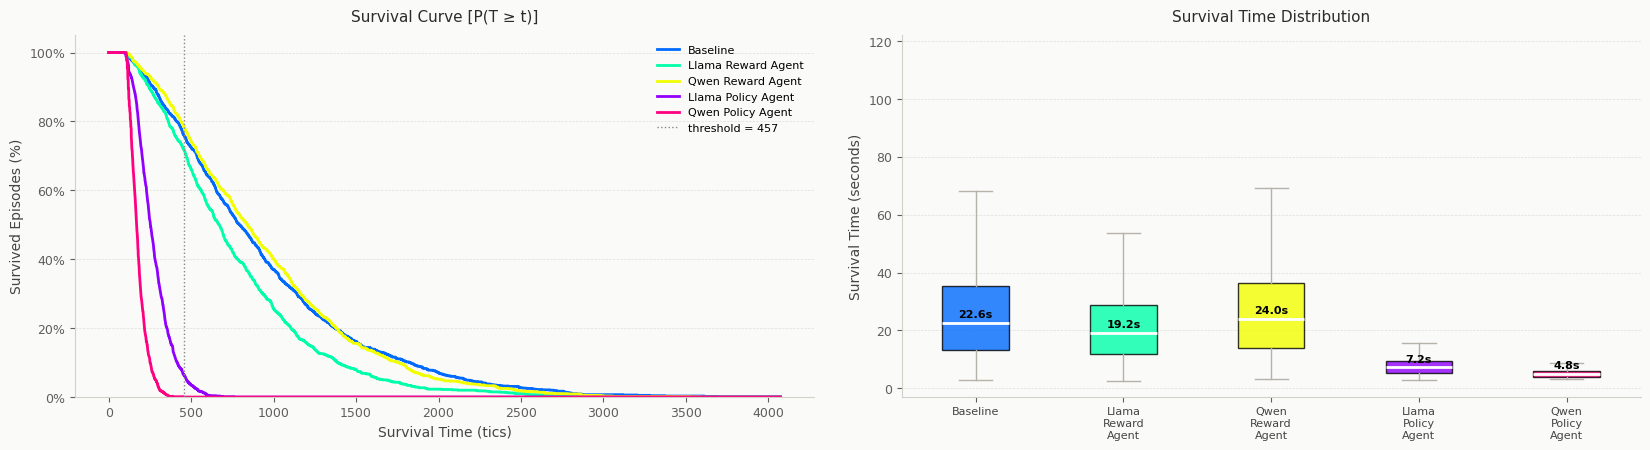


Plot saved to: ./logs/survival_analysis_all.png


In [12]:
# Full comparison table and plot
print("\nFull comparison")
print_stats_table(all_stats)
plot_results(all_survival_data, save_path="./logs/survival_analysis_all.png")

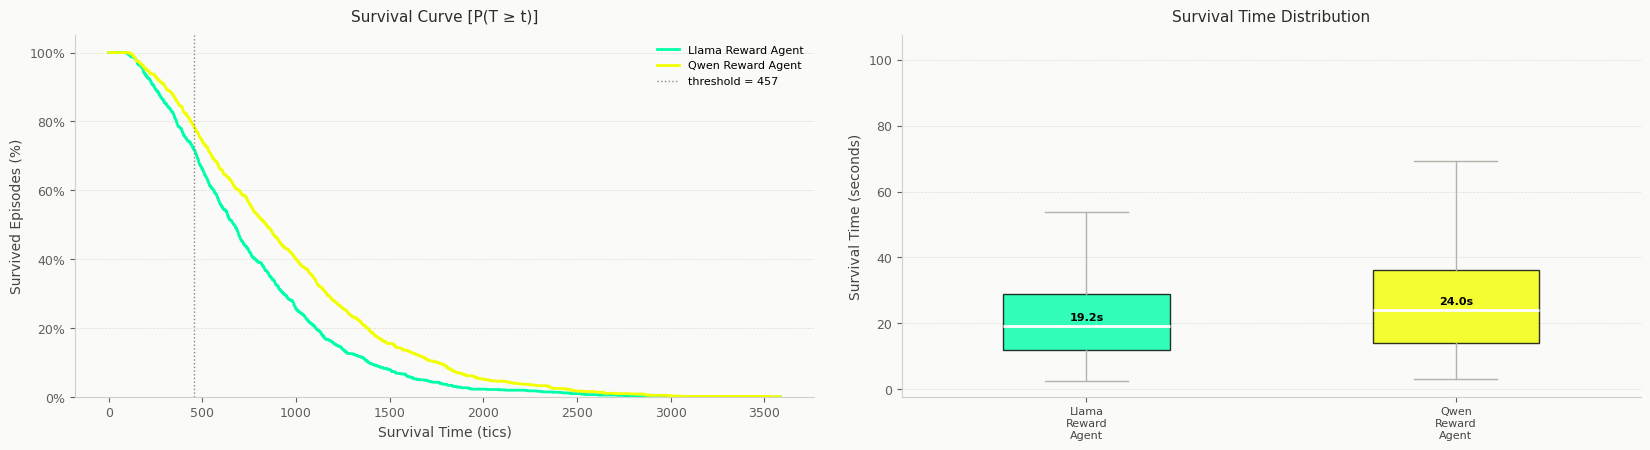


Plot saved to: ./logs/survival_reward_agents.png


In [13]:
# Sub-group plots
reward_agents = {k: all_survival_data[k] for k in ("Llama Reward Agent", "Qwen Reward Agent")}
policy_agents = {k: all_survival_data[k] for k in ("Llama Policy Agent", "Qwen Policy Agent")}

plot_results(reward_agents, save_path="./logs/survival_reward_agents.png")

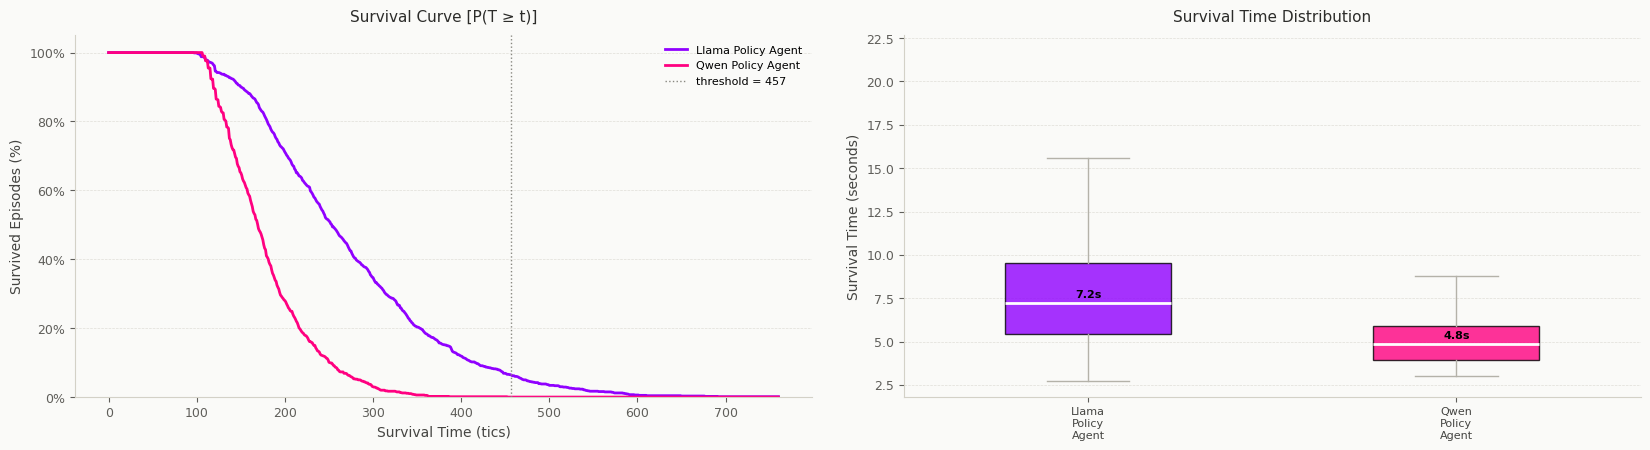


Plot saved to: ./logs/survival_policy_agents.png


In [14]:
plot_results(policy_agents, save_path="./logs/survival_policy_agents.png")